## Tesla EA Deliveries and Production Data(2015–2025)

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load The Data

In [4]:
df = pd.read_csv('C:\\Users\\imvc4\\Downloads\\tesla_deliveries_dataset_2015_2025.csv')

##  Data overview

In [8]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [9]:
df.shape

(2640, 12)

## Checking Data types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


## Checking Null Values

In [11]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## Checking Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [13]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Data Visualization

## Distribution of Avg Price

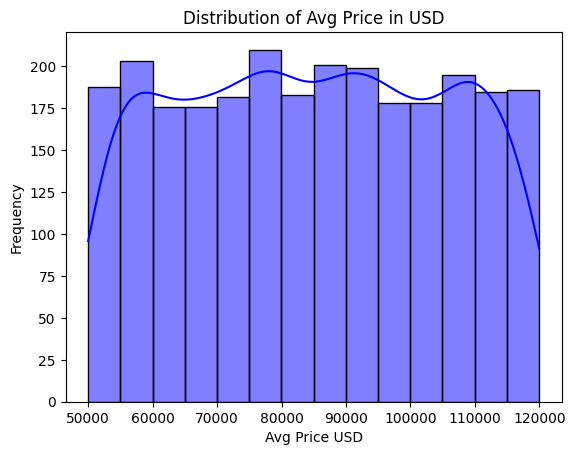

In [14]:
sns.histplot(df['Avg_Price_USD'],kde=True,color='blue')
plt.xlabel('Avg Price USD')
plt.ylabel('Frequency')
plt.title('Distribution of Avg Price in USD')
plt.show()

## Numeric Columns Distribution

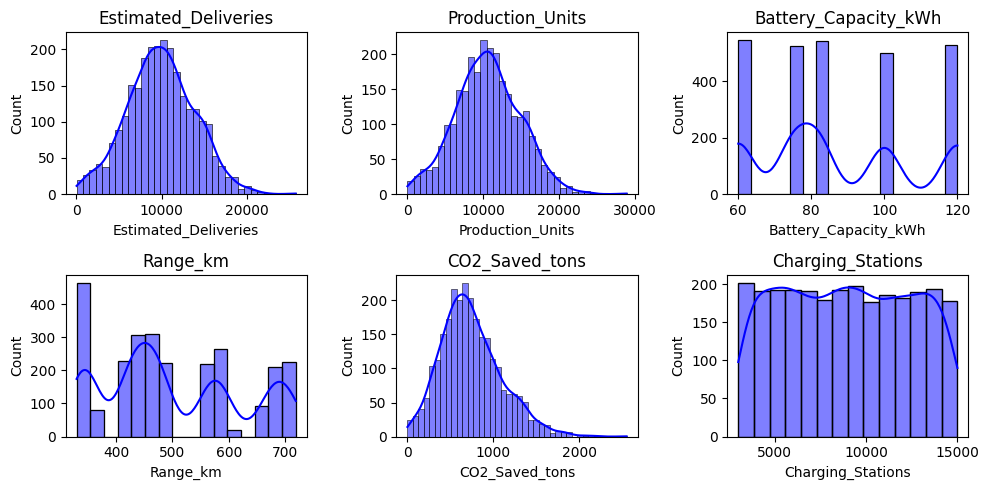

In [15]:
cols_hist = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_hist:
    plt.subplot(2,3,cols_hist.index(col)+1)
    sns.histplot(df[col],kde=True,color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

## Categorical Columns Distribution

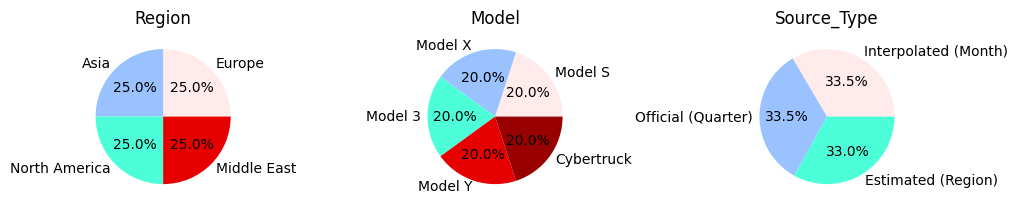

In [16]:
cols_pie = ['Region','Model','Source_Type']
plt.figure(figsize=(10,5))
for col in cols_pie:
    plt.subplot(1,3,cols_pie.index(col)+1)
    plt.pie(df[col].value_counts(),labels=df[col].value_counts().index,autopct='%1.1f%%', colors=['#FFEBEB',"#99C2FF","#4DFFD8",'#E60000','#990000'])
    plt.title(col)
plt.tight_layout()
plt.show()

## Avg Price USD By Region

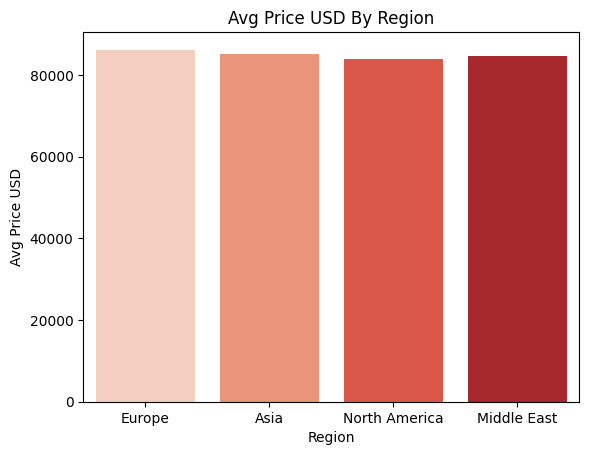

In [18]:
sns.barplot(x='Region',y='Avg_Price_USD',data=df , ci=False,palette='Reds')
plt.xlabel('Region')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Region')
plt.show()

## Avg Price USD By Mode

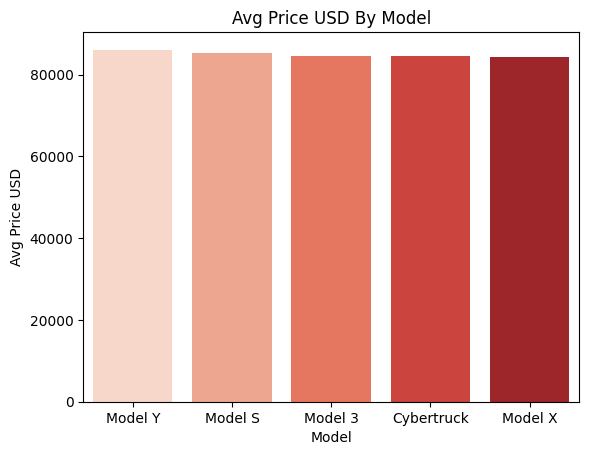

In [19]:
models = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)
sns.barplot(x=models.index,y=models.values,palette='Reds')
plt.xlabel('Model')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Model')
plt.show()

## Scatter Plots

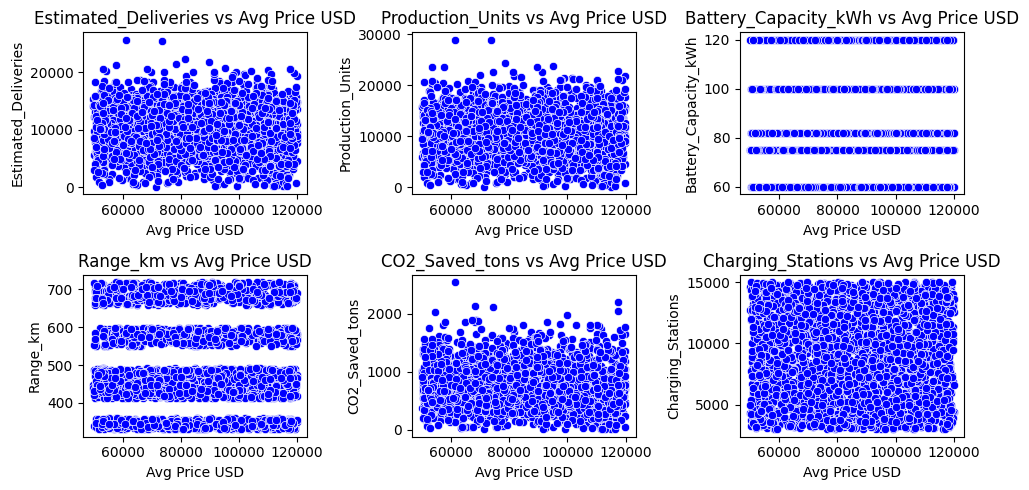

In [22]:
cols_scatter = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_scatter:
    plt.subplot(2,3,cols_scatter.index(col)+1)
    sns.scatterplot(x=df['Avg_Price_USD'],y=df[col],color='blue')
    plt.xlabel('Avg Price USD')
    plt.ylabel(col)
    plt.title(f'{col} vs Avg Price USD')
plt.tight_layout()
plt.show()

## Avg Price USD By Month

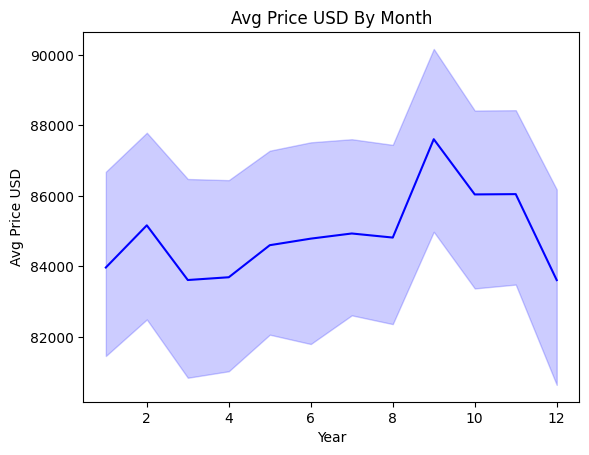

In [23]:
sns.lineplot(x='Month',y='Avg_Price_USD',data=df,color='blue')
plt.xlabel('Year')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Month')
plt.show()

## Avg Price USD By Year

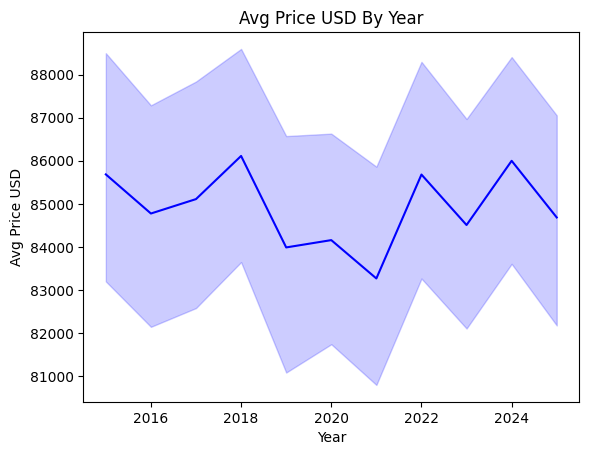

In [24]:
sns.lineplot(x='Year',y='Avg_Price_USD',data=df,color='blue')
plt.xlabel('Year')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Year')
plt.show()

In [25]:
df = pd.get_dummies(df,columns=['Region','Model','Source_Type'],drop_first=True,dtype=int)

In [26]:
df.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,1,0,0,0,1,0,0,1,0
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,0,0,0,0,0,1,0,0,1
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,0,0,1,0,0,1,0,1,0
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,0,0,1,1,0,0,0,0,1
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,0,1,0,0,0,0,1,0,0


In [27]:
df.shape

(2640, 18)

## Split + Train The Data

In [28]:
X = df.drop('Production_Units',axis=1)
y = df['Production_Units']

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score , mean_squared_error
print(f'R2 Score : {r2_score(y_test,y_pred)}')
print(f'MSE : {mean_squared_error(y_test,y_pred)}')

R2 Score : 0.988293345623036
MSE : 202265.6867076228


In [38]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(model,X,y,cv=5)
print(f'Cross Val Score : {cv_score}')
print(f'Mean Cross Val Score : {np.mean(cv_score)}')

Cross Val Score : [0.98876462 0.98839222 0.98700587 0.98838125 0.98904474]
Mean Cross Val Score : 0.9883177400837238


In [39]:
df_pred = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
df_pred.head()

,Actual,Predicted
2005,7968,7462.430862
32,10117,9989.011711
962,9355,9736.601978
1461,10171,9614.433607
478,9536,9313.015969
